In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('data/dataset.csv')
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [3]:
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(80)

In [5]:
df=df.drop_duplicates()

In [6]:
df.shape

(308774, 19)

In [7]:
df.nunique()

General_Health                     5
Checkup                            5
Exercise                           2
Heart_Disease                      2
Skin_Cancer                        2
Other_Cancer                       2
Depression                         2
Diabetes                           4
Arthritis                          2
Sex                                2
Age_Category                      13
Height_(cm)                       99
Weight_(kg)                      525
BMI                             3654
Smoking_History                    2
Alcohol_Consumption               31
Fruit_Consumption                 77
Green_Vegetables_Consumption      75
FriedPotato_Consumption           69
dtype: int64

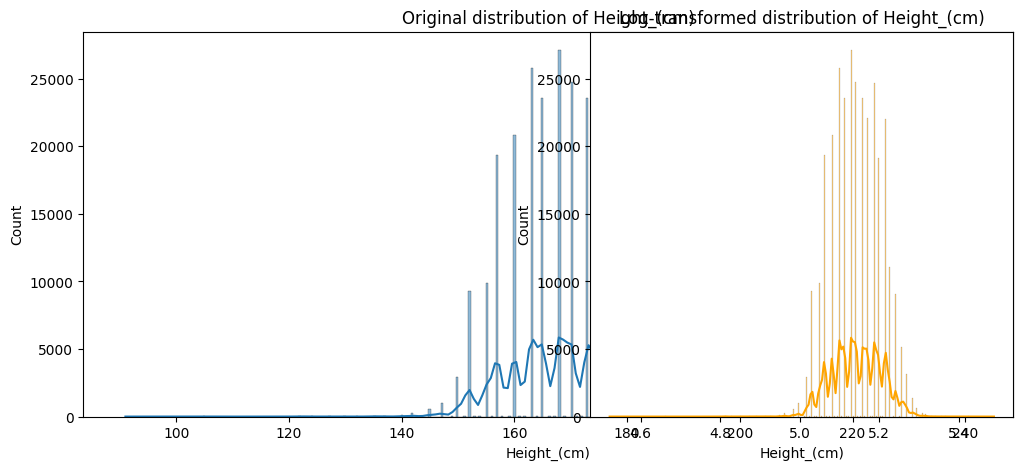

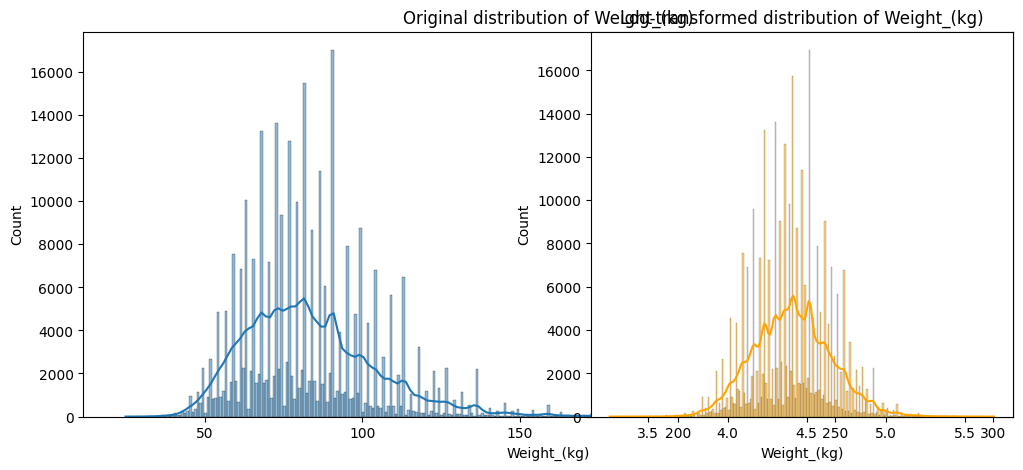

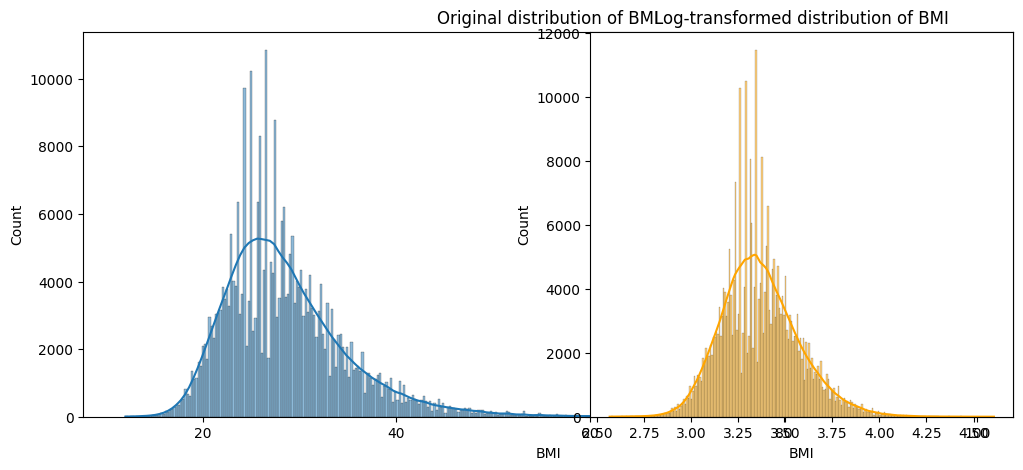

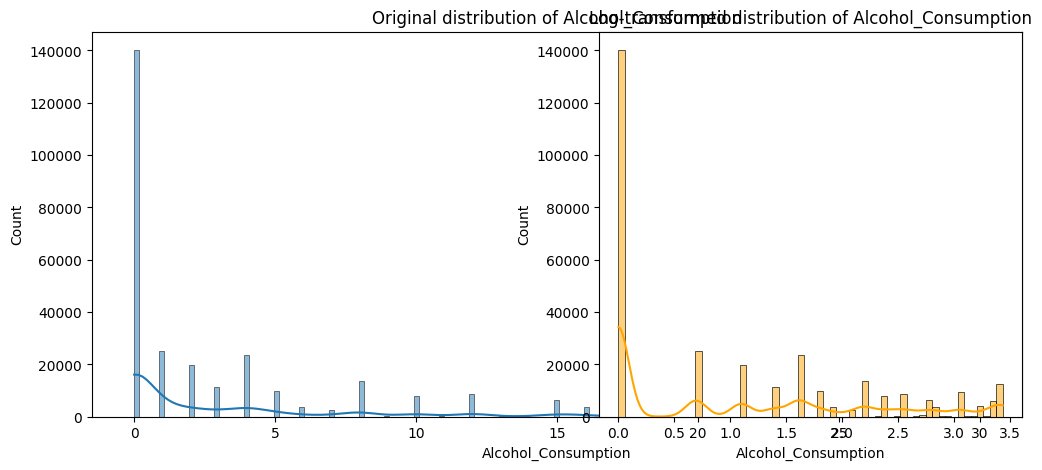

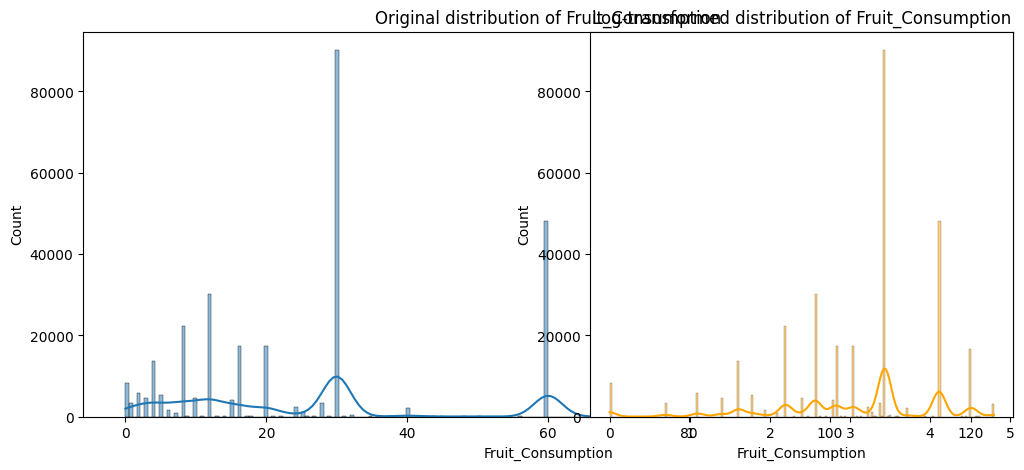

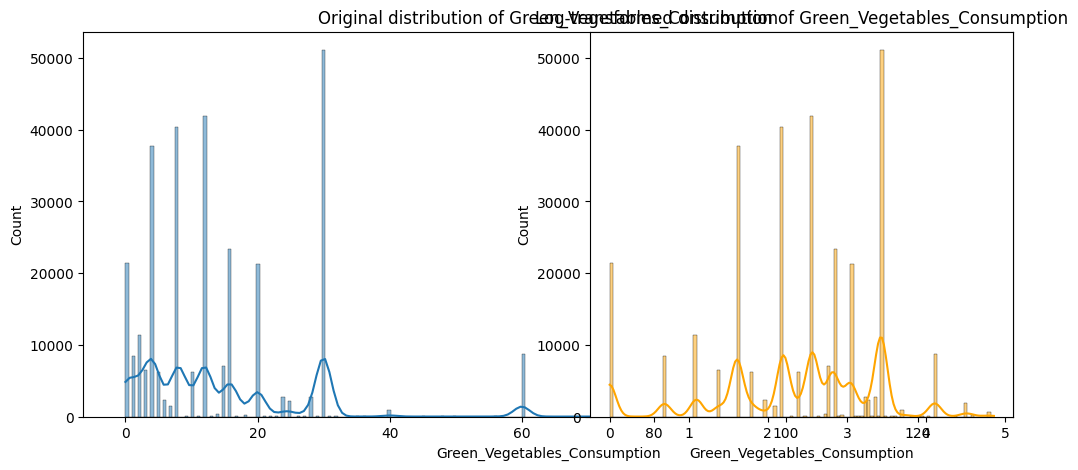

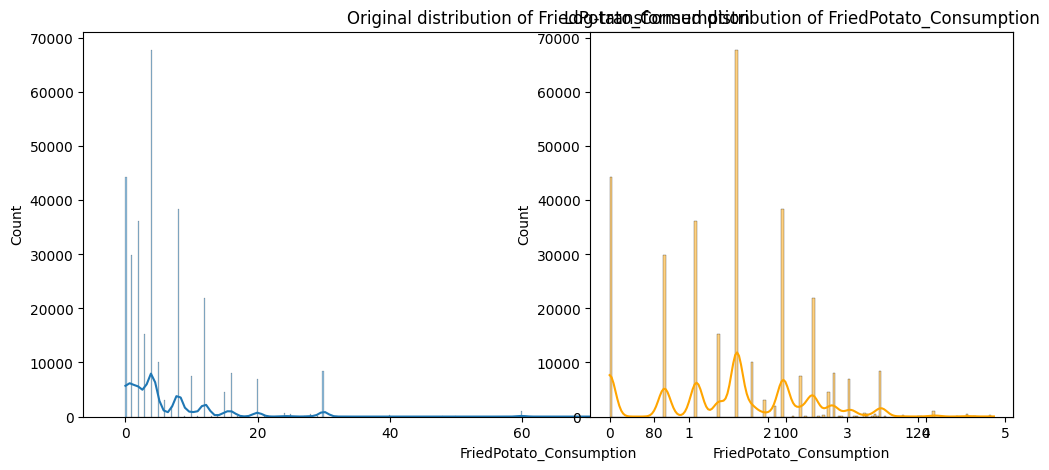

In [8]:
# Visualize skewness of important numerical/continuous features
numeric_cols = ['Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for col in numeric_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Original distribution of {col}')
    
    plt.subplot(1,2,2)

    # Apply log1p transformation (log(1+x)) to avoid log 0
    sns.histplot(np.log1p(df[col]), kde=True, color='orange')
    plt.title(f'Log-transformed distribution of {col}')

    plt.show()

In [9]:
# Apply transformation to reduce skew
for col in numeric_cols:
    df.loc[:,col+'_log'] = np.log1p(df[col]) # Creates new columns with log transform

In [10]:
# Check skewness after transformation
print('Skewness before and after log transform:')
for col in numeric_cols:
    print(f"{col}: Before={df[col].skew():.2f}, After={df[col+'_log'].skew():.2f}")

Skewness before and after log transform:
Height_(cm): Before=0.02, After=-0.20
Weight_(kg): Before=1.06, After=0.18
BMI: Before=1.38, After=0.48
Alcohol_Consumption: Before=1.89, After=0.65
Fruit_Consumption: Before=1.25, After=-0.87
Green_Vegetables_Consumption: Before=2.42, After=-0.62
FriedPotato_Consumption: Before=4.91, After=0.03


In [11]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Height_(cm)_log,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,...,30,16,12,5.017280,3.516310,2.743417,0.000000,3.433987,2.833213,2.564949
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,...,30,0,4,5.111988,4.358118,3.377246,0.000000,3.433987,0.000000,1.609438
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,...,12,3,16,5.099866,4.493680,3.540089,1.609438,2.564949,1.386294,2.833213
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,...,30,30,8,5.198497,4.547965,3.392157,0.000000,3.433987,3.433987,2.197225
4,Good,Within the past year,No,No,No,No,No,No,No,Male,...,8,4,0,5.257495,4.493680,3.233567,0.000000,2.197225,1.609438,0.000000


In [12]:
df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption',
       'Height_(cm)_log', 'Weight_(kg)_log', 'BMI_log',
       'Alcohol_Consumption_log', 'Fruit_Consumption_log',
       'Green_Vegetables_Consumption_log', 'FriedPotato_Consumption_log'],
      dtype='object')

In [13]:
# Drop the transformed height column
if 'Height_(cm)_log' in df.columns:
    df.drop('Height_(cm)_log', axis=1, inplace=True)

In [14]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,...,0,30,16,12,3.516310,2.743417,0.000000,3.433987,2.833213,2.564949
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,...,0,30,0,4,4.358118,3.377246,0.000000,3.433987,0.000000,1.609438
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,...,4,12,3,16,4.493680,3.540089,1.609438,2.564949,1.386294,2.833213
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,...,0,30,30,8,4.547965,3.392157,0.000000,3.433987,3.433987,2.197225
4,Good,Within the past year,No,No,No,No,No,No,No,Male,...,0,8,4,0,4.493680,3.233567,0.000000,2.197225,1.609438,0.000000


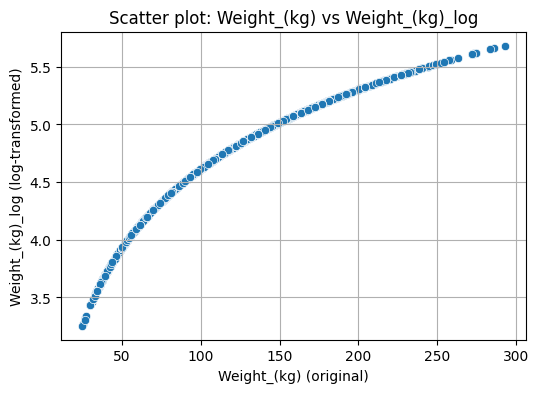

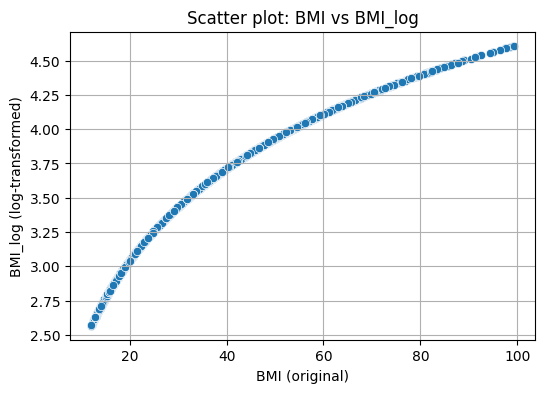

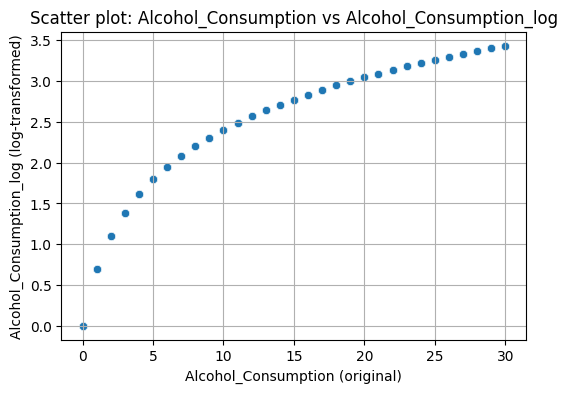

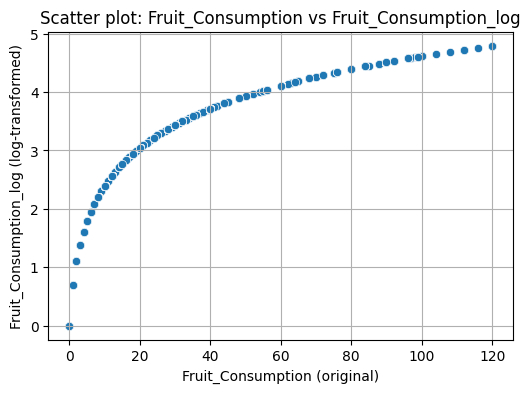

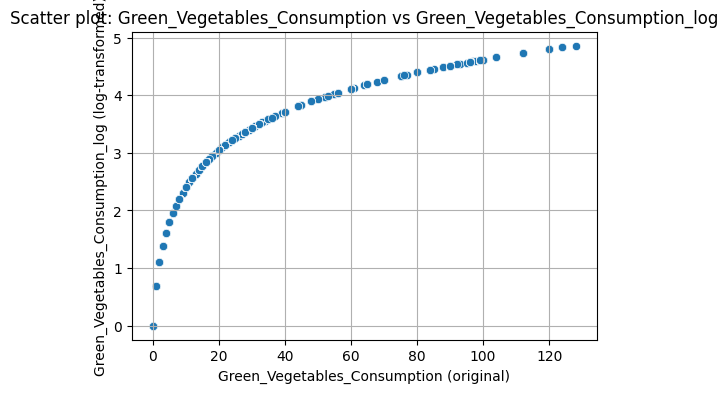

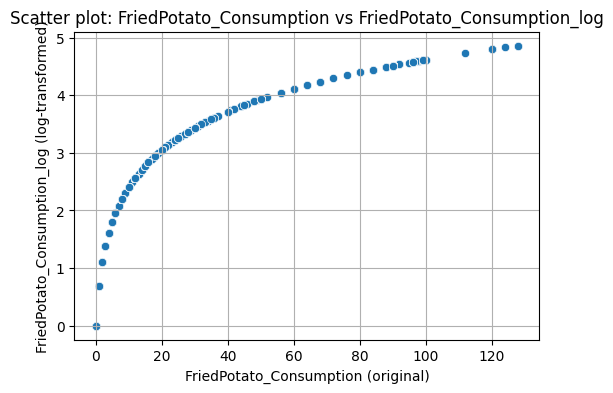

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df[col+'_log'])
    plt.title(f'Scatter plot: {col} vs {col}_log')
    plt.xlabel(f'{col} (original)')
    plt.ylabel(f'{col}_log (log-transformed)')
    plt.grid(True)
    plt.show()

## Shows monotonically increasing curve


## I decide to keep both original features and log-transformed features

    Original features capture the raw relationships
    Log-tranformed features help reduce skewness and might reveal linear relationship or reduce the influence of extreme outliers
    Soem models can benefit from both views of the data


In [17]:
print(df.dtypes)

General_Health                       object
Checkup                              object
Exercise                             object
Heart_Disease                        object
Skin_Cancer                          object
Other_Cancer                         object
Depression                           object
Diabetes                             object
Arthritis                            object
Sex                                  object
Age_Category                         object
Height_(cm)                           int64
Weight_(kg)                         float64
BMI                                 float64
Smoking_History                      object
Alcohol_Consumption                   int64
Fruit_Consumption                     int64
Green_Vegetables_Consumption          int64
FriedPotato_Consumption               int64
Weight_(kg)_log                     float64
BMI_log                             float64
Alcohol_Consumption_log             float64
Fruit_Consumption_log           

In [18]:
# Inspecting multi-categorical columns
multi_cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in multi_cat_cols:
    print(f"{col}:{df[col].unique()}")

General_Health:['Poor' 'Very Good' 'Good' 'Fair' 'Excellent']
Checkup:['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']
Exercise:['No' 'Yes']
Heart_Disease:['No' 'Yes']
Skin_Cancer:['No' 'Yes']
Other_Cancer:['No' 'Yes']
Depression:['No' 'Yes']
Diabetes:['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']
Arthritis:['Yes' 'No']
Sex:['Female' 'Male']
Age_Category:['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']
Smoking_History:['Yes' 'No']


In [19]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 13 numerical features : ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'Weight_(kg)_log', 'BMI_log', 'Alcohol_Consumption_log', 'Fruit_Consumption_log', 'Green_Vegetables_Consumption_log', 'FriedPotato_Consumption_log']

We have 12 categorical features : ['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']


In [20]:
df.to_csv('data/cleaned_data.csv', index=False)

In [21]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,...,0,30,16,12,3.516310,2.743417,0.000000,3.433987,2.833213,2.564949
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,...,0,30,0,4,4.358118,3.377246,0.000000,3.433987,0.000000,1.609438
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,...,4,12,3,16,4.493680,3.540089,1.609438,2.564949,1.386294,2.833213
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,...,0,30,30,8,4.547965,3.392157,0.000000,3.433987,3.433987,2.197225
4,Good,Within the past year,No,No,No,No,No,No,No,Male,...,0,8,4,0,4.493680,3.233567,0.000000,2.197225,1.609438,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,...,4,30,8,0,4.414615,3.402863,1.609438,3.433987,2.197225,0.000000
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,...,8,15,60,4,4.260565,3.112626,2.197225,2.772589,4.110874,1.609438
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,...,4,40,8,4,4.130837,3.246102,1.609438,3.713572,2.197225,1.609438
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,...,3,30,12,0,4.386765,3.208017,1.386294,3.433987,2.564949,0.000000


# In total 25 columns, we have:
- 13 numerical features in num_cols
- 6 binary features in binary_cols (excluding the target)
- 5 ordinal categorical features in ordinal_cols
- The target variable Heart_Disease to be used as y